# Deep learning project

This is a deep learning project established by Guillaume, Talib, and Cédric Manelli. The goal of this project is to build and compare deep learning models to automatically classify colorectal cancer histology images into nine tissue types.

## Data and library importation 

In [141]:
#pip install medmnist
from medmnist import PathMNIST

## 1) Data exploration
Importation of the dataset from medmnist library and exploration of them. 

In [142]:
from medmnist import INFO
data_flag = "pathmnist"
info = INFO[data_flag]

print(info)

{'python_class': 'PathMNIST', 'description': 'The PathMNIST is based on a prior study for predicting survival from colorectal cancer histology slides, providing a dataset (NCT-CRC-HE-100K) of 100,000 non-overlapping image patches from hematoxylin & eosin stained histological images, and a test dataset (CRC-VAL-HE-7K) of 7,180 image patches from a different clinical center. The dataset is comprised of 9 types of tissues, resulting in a multi-class classification task. We resize the source images of 3×224×224 into 3×28×28, and split NCT-CRC-HE-100K into training and validation set with a ratio of 9:1. The CRC-VAL-HE-7K is treated as the test set.', 'url': 'https://zenodo.org/records/10519652/files/pathmnist.npz?download=1', 'MD5': 'a8b06965200029087d5bd730944a56c1', 'url_64': 'https://zenodo.org/records/10519652/files/pathmnist_64.npz?download=1', 'MD5_64': '55aa9c1e0525abe5a6b9d8343a507616', 'url_128': 'https://zenodo.org/records/10519652/files/pathmnist_128.npz?download=1', 'MD5_128': 

Let separate dataset to a cohorte for the deep learning project. The dataset have an initialized cohorte with train, val and test.

In [143]:
train = PathMNIST(split="train", download=True)
val = PathMNIST(split="val", download=True)
test = PathMNIST(split="test", download=True)

# extract the images and labels from the datasets
train_images = train.imgs
train_labels = train.labels
val_images = val.imgs
val_labels = val.labels
test_images = test.imgs
test_labels = test.labels

Use the train dataset to analyse images and get informations

In [144]:
# get image shape
train_images.shape

(89996, 28, 28, 3)

It's ineresting to explore all of classes. We have 9 classes '0' adipose', '1': 'background', '2': 'debris', '3': 'lymphocytes', '4': 'mucus', '5': 'smooth muscle', '6': 'normal colon mucosa', '7': 'cancer-associated stroma', '8': 'colorectal adenocarcinoma epithelium'

C:\Users\MANEL\AppData\Local\Temp\ipykernel_25368\854996401.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(label)


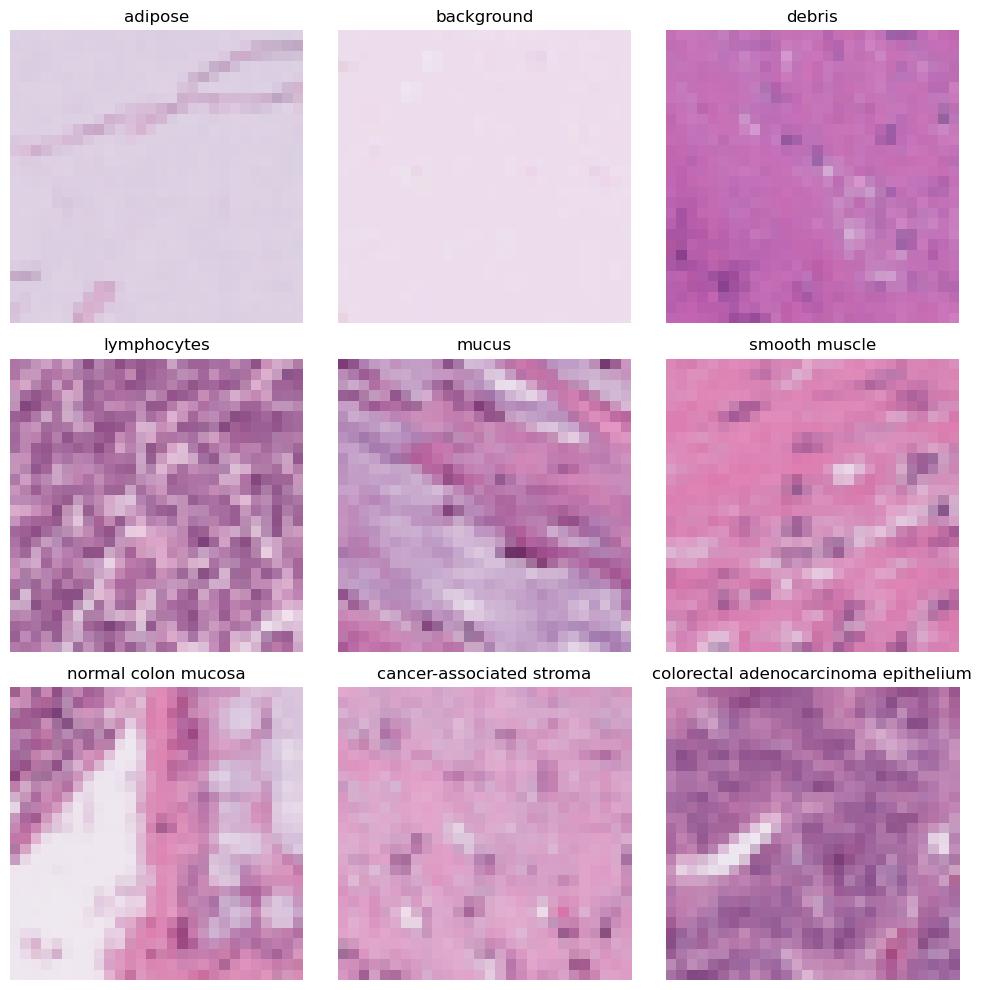

In [145]:

# Display one image per class
import matplotlib.pyplot as plt

num_classes = 9
class_images = [None] * num_classes
# find one image per class
for img, label in zip(train_images, train_labels):
    label = int(label)
    if class_images[label] is None:
        class_images[label] = img
    if all(x is not None for x in class_images):
        break

labels_names = info["label"]

# plot the images
plt.figure(figsize=(10,10))

for i in range(num_classes):
    plt.subplot(3,3,i+1)
    plt.imshow(class_images[i])
    plt.title(labels_names.get(str(i)))
    plt.axis("off")

plt.tight_layout()
plt.show()

Look at several images from the 'debris' class and several from 'background' class

C:\Users\MANEL\AppData\Local\Temp\ipykernel_25368\3835005171.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(label)


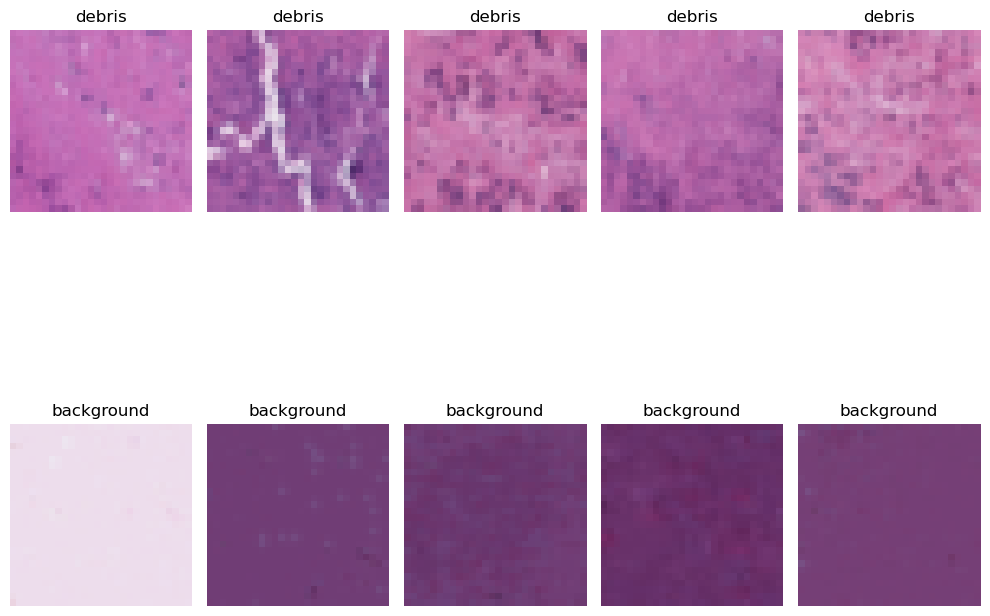

In [146]:
# look several images of the class "debris" and the class "background"
debris_images = []
background_images = []
i=0
j=0
for img, label in zip(train_images, train_labels):
    label = int(label)
    if label == 2:
        debris_images.append(img)
        i += 1
    elif label == 1:
        background_images.append(img)
        j += 1
    if i == 5 and j == 5:
        break
# plot the images
plt.figure(figsize=(10,10))
for i in range(5):
    plt.subplot(2, 5, i+1)
    plt.imshow(debris_images[i])
    plt.title("debris")
    plt.axis("off")
for i in range(5):
    plt.subplot(2, 5, i+6)
    plt.imshow(background_images[i])
    plt.title("background")
    plt.axis("off")
plt.tight_layout()
plt.show()

**Debris images**

The debris samples show irregular structures and local patterns. Several images contain:

- fragmented or granular textures
- small dark clusters that may correspond to cell fragments or nuclei remnants
- irregular line-like or branching structures
- non-uniform color distribution
Some tiles also show thin bright boundaries or streaks, suggesting pieces of tissue or staining artifacts.

**Background images**

In contrast, the background images appear structurally empty. They are characterized by:
- nearly uniform color
- absence of identifiable structures
- very smooth texture
- minimal spatial variation in pixel intensity.

These tiles likely correspond to empty regions of the slide where no tissue is present.

8


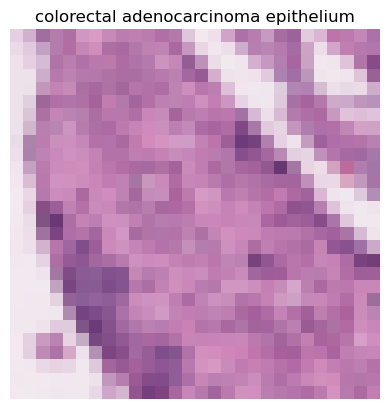

In [147]:
# pick any image from training dataset display it
import numpy as np
#pick an image
random_number = np.random.randint(0, len(train_images))
image_rdm = train_images[random_number]
label_rdm = train_labels[random_number]
print(label_rdm[0])
# display the image
plt.imshow(image_rdm)
plt.axis("off")
plt.title(labels_names.get(str(label_rdm[0])))
plt.show()

In [148]:
# report the pixel intensity statistics: mean and standard deviation per channel
means = np.mean(image_rdm, axis=(0,1))
stds = np.std(image_rdm, axis=(0,1))
print("Mean per channel:", means)
print("Standard deviation per channel:", stds)

Mean per channel: [190.72959184 138.99617347 182.61734694]
Standard deviation per channel: [28.57510408 43.28558151 27.42938996]


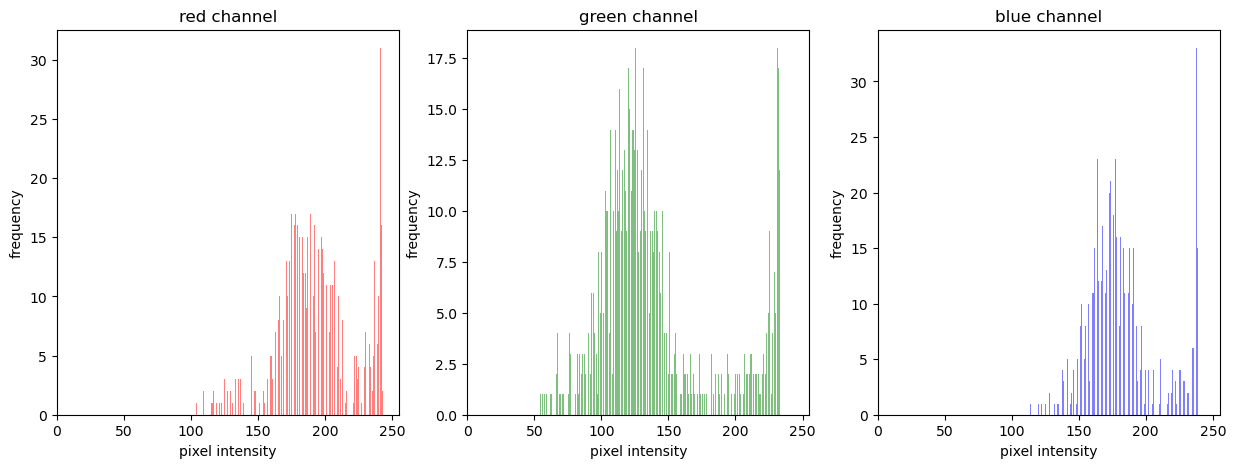

In [149]:
# plot the histogram of pixel intensities for each channel
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.hist(image_rdm[:,:,0].flatten(), bins=256, color='red', alpha=0.5)
plt.xlabel("pixel intensity")
plt.ylabel("frequency")
plt.xlim(0, 255)
plt.title("red channel")
plt.subplot(1,3,2)
plt.hist(image_rdm[:,:,1].flatten(), bins=256, color='green', alpha=0.5)
plt.xlabel("pixel intensity")
plt.ylabel("frequency")
plt.xlim(0, 255)
plt.title("green channel")
plt.subplot(1,3,3)
plt.hist(image_rdm[:,:,2].flatten(), bins=256, color='blue', alpha=0.5)
plt.xlabel("pixel intensity")
plt.ylabel("frequency")
plt.xlim(0, 255)
plt.title("blue channel")
plt.show()

mean: [188.83897503 135.91045926 179.98635682]
std: [31.53896524 45.07444572 31.72982184]


Value with normalisation
mean normalized: [0.740545   0.53298219 0.70582885]
std normalized: [0.12368222 0.17676253 0.12443067]


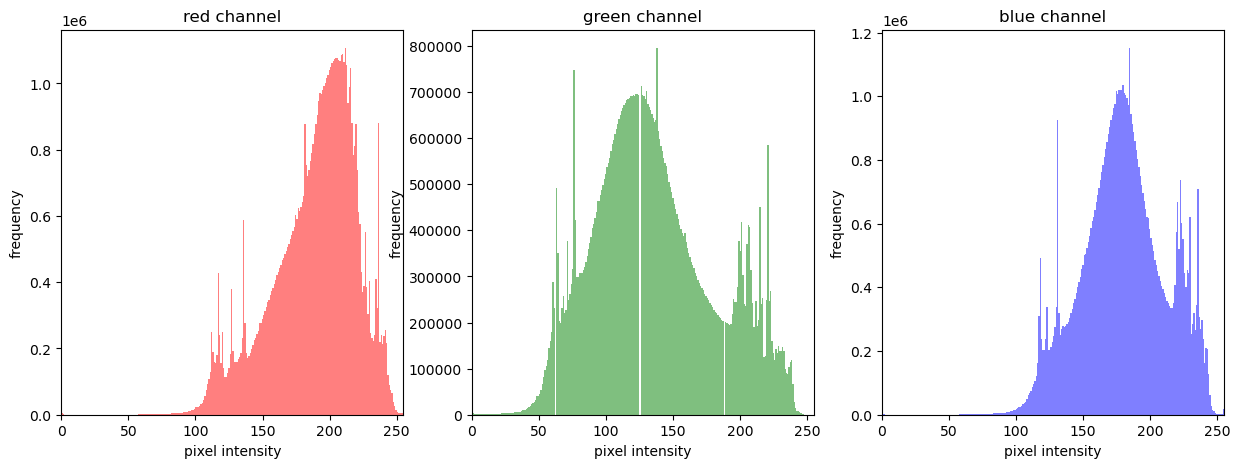

In [150]:
# generelyze for all the images in the training dataset.
mean = np.mean(train_images, axis=(0,1,2))
std = np.std(train_images, axis=(0,1,2))
print("mean:", mean)
print("std:", std)
mean_norm = mean / 255.0
std_norm = std / 255.0
print("\n")
print("Value with normalisation")
print("mean normalized:", mean_norm)
print("std normalized:", std_norm)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.hist(train_images[:,:,:,0].flatten(), bins=256, color='red', alpha=0.5)
plt.xlabel("pixel intensity")
plt.ylabel("frequency")
plt.xlim(0, 255)
plt.title("red channel")
plt.subplot(1,3,2)
plt.hist(train_images[:,:,:,1].flatten(), bins=256, color='green', alpha=0.5)
plt.xlabel("pixel intensity")
plt.ylabel("frequency")
plt.xlim(0, 255)
plt.title("green channel")
plt.subplot(1,3,3)
plt.hist(train_images[:,:,:,2].flatten(), bins=256, color='blue', alpha=0.5)
plt.xlabel("pixel intensity")
plt.ylabel("frequency")
plt.xlim(0, 255)
plt.title("blue channel")
plt.show()

The mean and standard deviation of pixel intensities were computed for a randomly selected training image. The obtained values were approximately mean = [188.8, 135.9, 180.0] and standard deviation = [31.5, 45.1, 31.7] in the [0,255] range. When rescaled to the [0,1] range, the mean values are around [0.74, 0.53, 0.71] and the standard deviations around [0.12, 0.18, 0.12]. These statistics differ from the commonly used normalization values derived from ImageNet (mean ≈ [0.485, 0.456, 0.406], std ≈ [0.229, 0.224, 0.225]). This difference is expected because histology images exhibit characteristic color distributions caused by hematoxylin–eosin staining, resulting in dominant pink and purple tones. Consequently, ImageNet normalization may not be optimal for this dataset, and it is preferable to compute dataset-specific statistics across the entire training set before training the convolutional neural network.

## 3) CNN from scratch

In this part, we will design and train a convolutional neural network with proper regularization.

### 3.1) Data prepratation

In [151]:
# Data preparation:
# Normalized data loaders
import torch
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# define the transformations for normalisation
transform_norm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean_norm, std_norm)
])
# create the datasets with the transformations
train_ds_norm = PathMNIST(split='train', transform=transform_norm, download=True)
val_ds_norm = PathMNIST(split='val', transform=transform_norm, download=True)
test_dataset = PathMNIST(split='test', transform=transform_norm, download=True)

# create the data loaders
batch_size = 128
train_loader_mlp = DataLoader(train_ds_norm, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader_mlp = DataLoader(val_ds_norm, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader_mlp = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)



In [152]:
# define train model function
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

# Confusion matrix function
def plot_confusion_matrix(model, data_loader, title="Confusion Matrix", labels_names=labels_names):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in data_loader:
            xb = xb.to(device)
            yb = yb.squeeze().long().to(device)
            out = model(xb)
            all_preds.append(out.argmax(1).cpu())
            all_labels.append(yb.cpu())
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(16, 14))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_names.values())
    disp.plot(ax=ax, cmap=plt.cm.Blues, colorbar=True)
    ax.set_xticklabels(labels_names.values(), rotation=90, ha="center", fontsize = 14)
    ax.set_yticklabels(labels_names.values(), fontsize = 14)
    ax.set_title(title, fontsize=25)
    ax.set_xlabel('Predicted', fontsize=18)
    ax.set_ylabel('True', fontsize=18)
    plt.tight_layout()
    plt.show()

# define train model function
def train_model(model, train_loader, val_loader, epochs=30, lr=1e-3, labels_names=labels_names):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        # Training
        model.train()
        loss_sum, correct, total = 0, 0, 0
        for xb, yb in train_loader:
            xb = xb.to(device) 
            yb = yb.squeeze().long().to(device)
            out = model(xb)
            loss = criterion(out, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss_sum += loss.item() * len(xb)
            correct += (out.argmax(1) == yb).sum().item()
            total += len(xb)
        history["train_loss"].append(loss_sum / total)
        history["train_acc"].append(correct / total)

        # Validation
        model.eval()
        loss_sum, correct, total = 0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb= xb.to(device)
                yb = yb.squeeze().long().to(device)
                out = model(xb)
                loss = criterion(out, yb)
                loss_sum += loss.item() * len(xb)
                correct += (out.argmax(1) == yb).sum().item()
                total += len(xb)
        history["val_loss"].append(loss_sum / total)
        history["val_acc"].append(correct / total)

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}/{epochs} — "
                  f"train_acc: {history['train_acc'][-1]:.3f}, "
                  f"val_acc: {history['val_acc'][-1]:.3f}")
            
    plot_confusion_matrix(
        model = model,
        data_loader = val_loader,
        title=f"Confusion Matrix",
        labels_names = labels_names
    )

    return history

Using device: cpu


In [153]:
# create the function to plot the training history
def plot_history(history, title=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history["train_loss"], label="Train")
    ax1.plot(history["val_loss"],   label="Val")
    ax1.set_title(f"{title} — Loss"); ax1.legend()
    ax2.plot(history["train_acc"], label="Train")
    ax2.plot(history["val_acc"],   label="Val")
    ax2.set_title(f"{title} — Accuracy"); ax2.legend()
    plt.tight_layout(); plt.show()

In [154]:
# define the MLP model from sratch with least 2 hidden layers and dropout
class DenseNetwork(nn.Module):
    """MLP with 3 hidden layers and dropout."""
    def __init__(self, input_dim=3*28*28, n_classes=9):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)
# print the model summary
mlp_model = DenseNetwork()
print(mlp_model)


DenseNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=2352, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=128, out_features=9, bias=True)
  )
)


In [ ]:
print("Training MLP model...")
history_mlp = train_model(mlp_model, train_loader_mlp, val_loader_mlp, epochs=30, lr=1e-3, labels_names=labels_names)
plot_history(history_mlp, title="2) MLP with 3 hidden Layers")

Training MLP model...


KeyboardInterrupt: 

In [ ]:
print("===== REPORT VALUES =====")
print("Exact values of the validation loss at epoch 1, epoch 10 and the final epoch.")
print(f"Epoch 1  - val_loss: {history_mlp['val_loss'][0]}")
print(f"Epoch 10 - val_loss: {history_mlp['val_loss'][9]}")
print(f"Final epoch ({len(history_mlp['val_loss'])}) - val_loss: {history_mlp['val_loss'][-1]}")
print("Exact values of the validation accuracy at the same epochs.")
print(f"Epoch 1  - val_acc: {history_mlp['val_acc'][0]}")
print(f"Epoch 10 - val_acc: {history_mlp['val_acc'][9]}")
print(f"Final epoch ({len(history_mlp['val_acc'])}) - val_acc: {history_mlp['val_acc'][-1]}")

===== REPORT VALUES =====
Exact values of the validation loss at epoch 1, epoch 10 and the final epoch.
Epoch 1  - val_loss: 1.038558492132398


IndexError: list index out of range

Highest misclassification cell:
  - True class: 6 (normal colon mucosa)
  - Predicted class: 8 (colorectal adenocarcinoma epithelium)
  - Count: 389

This confusion likely occurs because both tissue types share similar color profiles
(H&E staining produces overlapping pink/purple tones) and at 28x28 resolution,
fine structural differences are hard to distinguish with a simple MLP that has
no spatial awareness.